# Phase 1 — Exploratory Data Analysis
**Project:** Nexus Telcom Insight : Telecom Complaint Analytics & Network Intelligence Platform  
**Author:** Ouerghi Chaima

---
## Table of Contents
1. Environment Setup
2. Data Loading
3. Complaint Dataset EDA
4. KPI Dataset EDA
5. Data Quality Audit


## 1. Environment Setup

In [ ]:
import sys
sys.path.insert(0, '../..') 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('Environment ready ✓')

Environment ready ✓


## 2. Data Loading

In [2]:
from src.ingestion.data_loader import load_complaints, load_kpi_data, get_data_summary

complaints = load_complaints()
kpi_data   = load_kpi_data()

get_data_summary(complaints, 'Complaint Dataset')
get_data_summary(kpi_data,   'KPI Dataset')

2026-03-25 08:18:23.579 | WARNING  | src.ingestion.data_loader:_resolve_data_path:26 - Real data not found — loading synthetic data from data/synthetic/
2026-03-25 08:18:23.580 | WARNING  | src.ingestion.data_loader:_resolve_data_path:27 - Replace data/synthetic/ files with real Huawei data when available.
2026-03-25 08:18:23.581 | INFO     | src.ingestion.data_loader:load_complaints:38 - Loading complaints from data\synthetic\complaints.csv
2026-03-25 08:18:23.870 | SUCCESS  | src.ingestion.data_loader:load_complaints:52 - Complaints loaded: 50,000 rows × 20 columns
2026-03-25 08:18:23.871 | WARNING  | src.ingestion.data_loader:_resolve_data_path:26 - Real data not found — loading synthetic data from data/synthetic/
2026-03-25 08:18:23.872 | WARNING  | src.ingestion.data_loader:_resolve_data_path:27 - Replace data/synthetic/ files with real Huawei data when available.
2026-03-25 08:18:23.873 | INFO     | src.ingestion.data_loader:load_kpi_data:67 - Loading KPI data from data\synthetic


  Complaint Dataset
  Shape         : 50,000 rows × 20 columns
  Date range    : 2023-01-01 00:05:55 → 2024-06-29 23:23:09

  Missing values:
    complaint_subcategory                1,522  (3.0%)
    latitude                             1,448  (2.9%)
    longitude                            1,466  (2.9%)
    cell_id                              1,568  (3.1%)


  KPI Dataset
  Shape         : 552,633 rows × 22 columns
  Date range    : 2023-01-01 00:01:00 → 2024-06-29 23:59:00

  Missing values:
    dl_throughput_mbps                  10,957  (2.0%)
    latency_ms                          11,109  (2.0%)
    call_drop_rate                      11,238  (2.0%)
    voice_quality_score_mos             10,940  (2.0%)



In [ ]:
print('COMPLAINTS — first 3 rows:')
display(complaints.head(3))
print('\nKPI DATA — first 3 rows:')
display(kpi_data.head(3))

COMPLAINTS — first 3 rows:


,case_id,timestamp,service_type,complaint_category,complaint_subcategory,region,city,latitude,longitude,cell_id,customer_segment,priority,msisdn,_hotspot_multiplier,date,hour,day_of_week,week,month,year
0,CASE_0035623,2023-01-01 00:05:55,Sms,Sms Failure,Encoding Error,Sousse,Sousse,35.86191,10.61071,CELL_0178,Standard,Low,21649928010,1.5,2023-01-01,0,Sunday,52,1,2023
1,CASE_0025986,2023-01-01 01:40:37,Data,No Service,Coverage Gap,Sousse,Sousse,35.87053,10.62839,CELL_0053,Standard,Low,21697233883,1.5,2023-01-01,1,Sunday,52,1,2023
2,CASE_0025907,2023-01-01 02:16:48,Voice,Call Setup Failure,Congestion,Gabes,Gabes,33.97918,10.00962,CELL_0053,Standard,High,21652745842,1.0,2023-01-01,2,Sunday,52,1,2023



KPI DATA — first 3 rows:


,msisdn,timestamp,cell_id,region,dl_throughput_mbps,ul_throughput_mbps,latency_ms,packet_loss_pct,data_session_success_rate,data_qoe_score,...,voice_quality_score_mos,handover_success_rate,voice_qoe_score,qoe_score,qoe_category,is_degraded_session,date,hour,month,year
0,21692636645,2023-01-01 00:01:00,CELL_0137,Sfax,33.742,7.800,50.3,0.559,96.67,84.32,...,3.79,97.61,88.62,86.25,Good,0,2023-01-01,0,1,2023
1,21631778568,2023-01-01 00:03:00,CELL_0189,Sousse,5.788,4.088,25.6,3.538,96.22,59.94,...,3.24,96.34,86.92,72.08,Fair,0,2023-01-01,0,1,2023
2,21663201230,2023-01-01 00:05:00,CELL_0064,Kairouan,10.198,2.971,21.2,0.382,94.95,69.30,...,3.63,97.41,82.30,75.15,Fair,0,2023-01-01,0,1,2023


## 3. Complaint Dataset EDA

In [4]:
from src.analysis.eda import (
    complaint_category_distribution,
    complaint_by_service_type,
    complaint_volume_over_time,
    complaint_heatmap_hour_day,
    complaint_by_region,
    missing_value_report,
)

2026-03-25 08:18:25.856 | INFO     | src.analysis.eda:complaint_category_distribution:51 - Figure saved → reports\figures\complaint_category_distribution.png


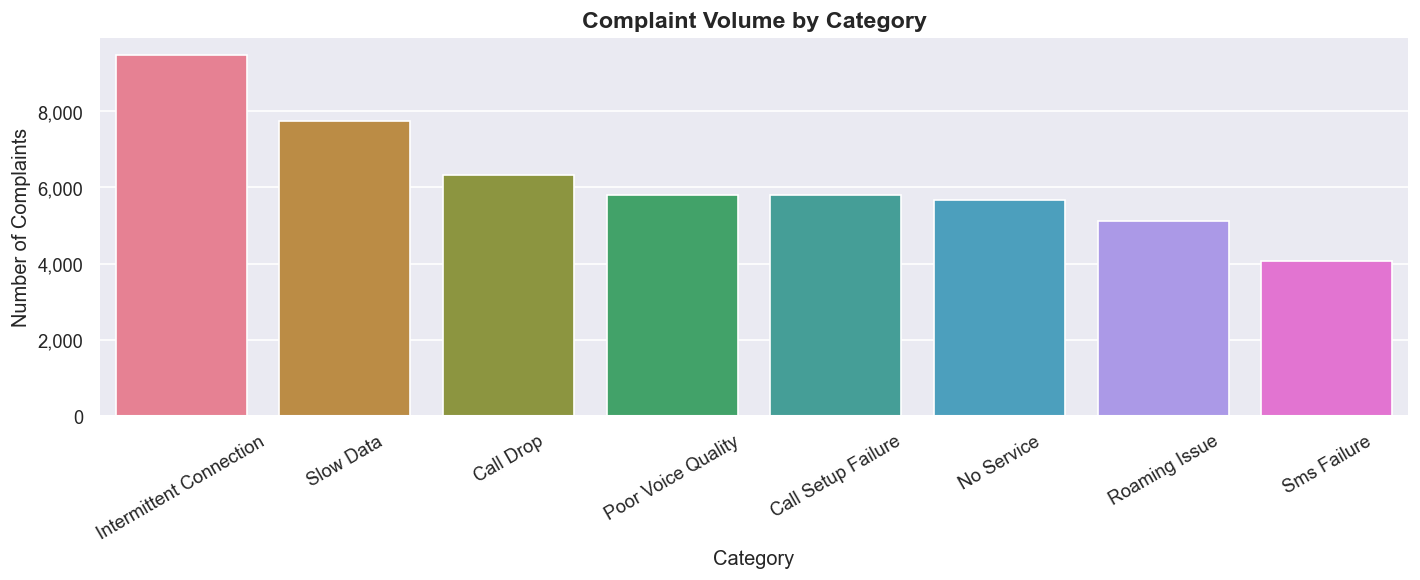

complaint_category
Intermittent Connection    9472
Slow Data                  7742
Call Drop                  6328
Poor Voice Quality         5805
Call Setup Failure         5797
No Service                 5681
Roaming Issue              5119
Sms Failure                4056
Name: count, dtype: int64


In [ ]:
#Category distribution
fig = complaint_category_distribution(complaints)
plt.show()
print(complaints['complaint_category'].value_counts())

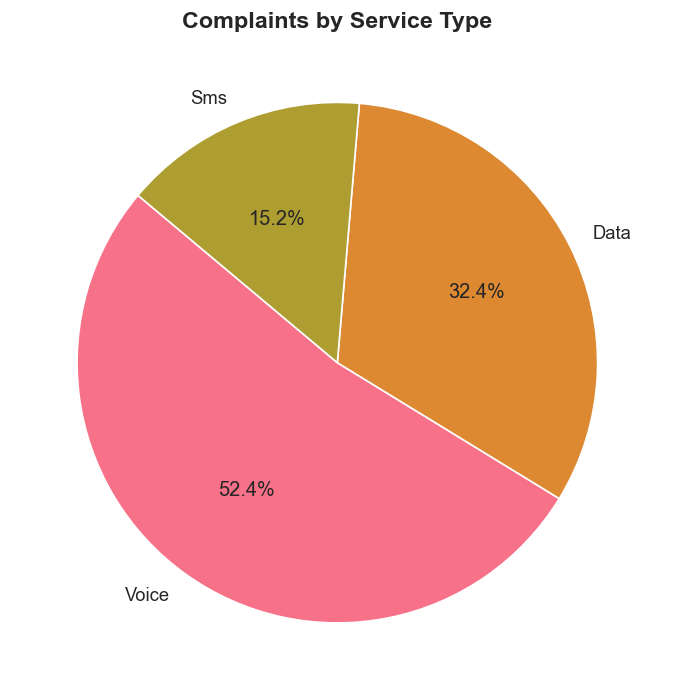

In [ ]:
#Service type split
fig = complaint_by_service_type(complaints)
plt.show()

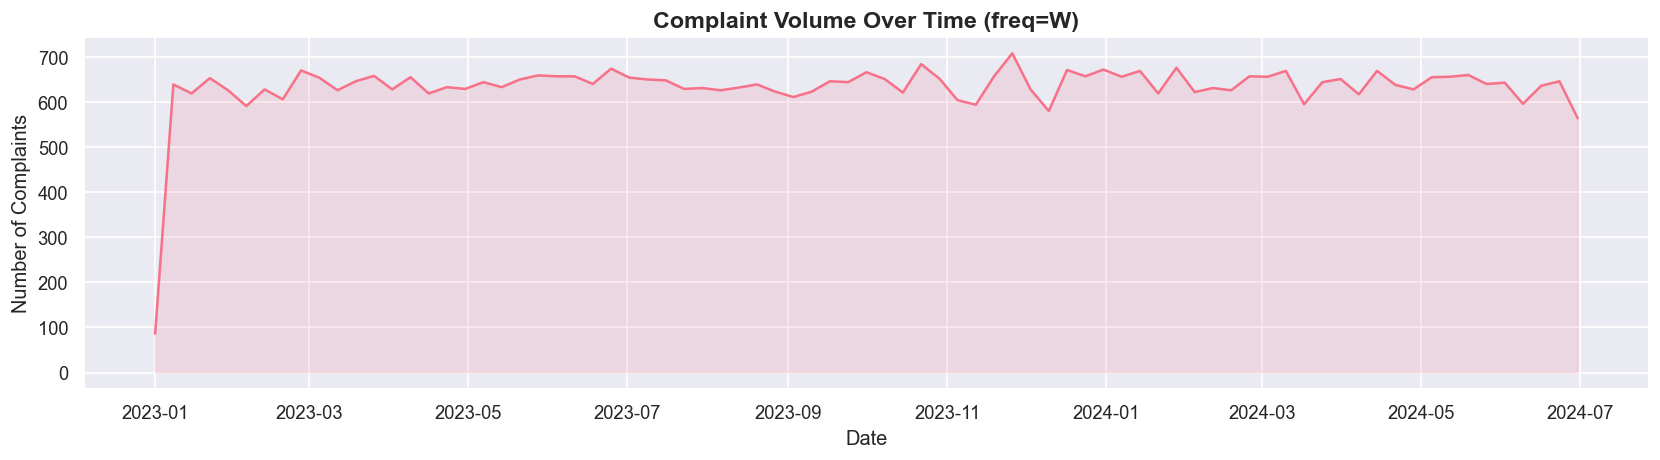

In [ ]:
#Volume over time (weekly)
fig = complaint_volume_over_time(complaints, freq='W')
plt.show()

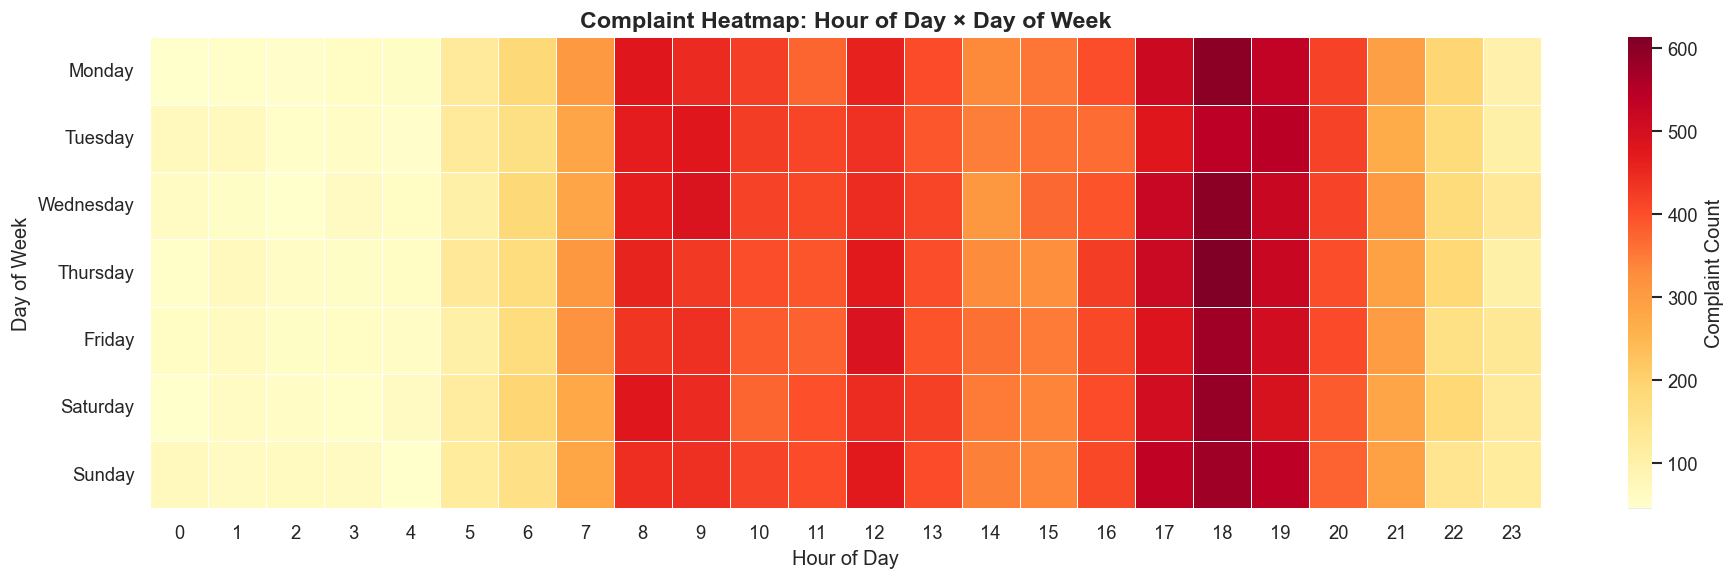

In [ ]:
#Hour × Day heatmap
fig = complaint_heatmap_hour_day(complaints)
plt.show()

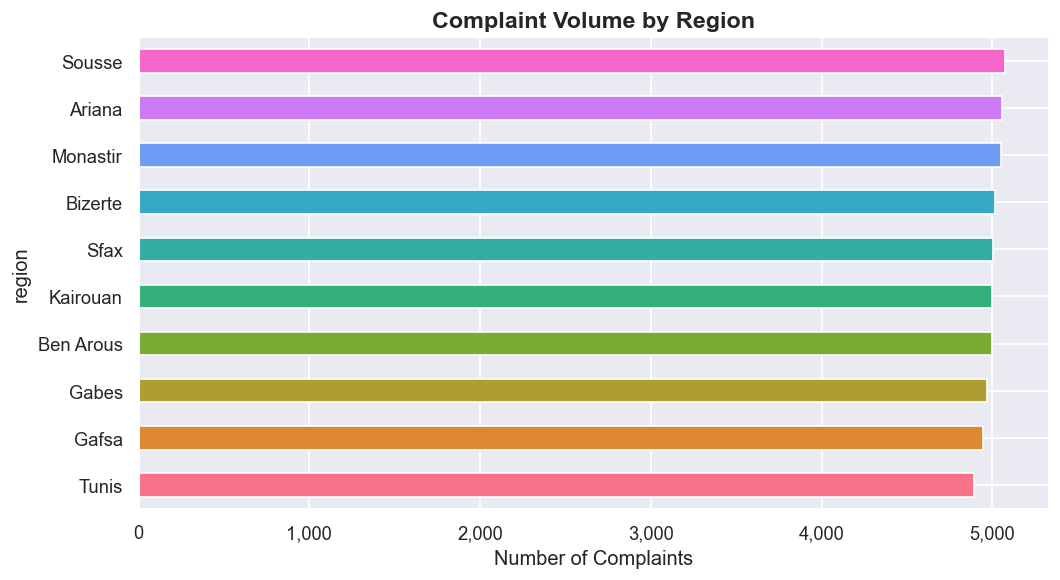

In [ ]:
#By region
fig = complaint_by_region(complaints)
plt.show()

## 4. KPI Dataset EDA

2026-03-25 08:18:29.533 | INFO     | src.analysis.eda:kpi_distribution_plots:176 - Figure saved → reports\figures\kpi_distributions.png


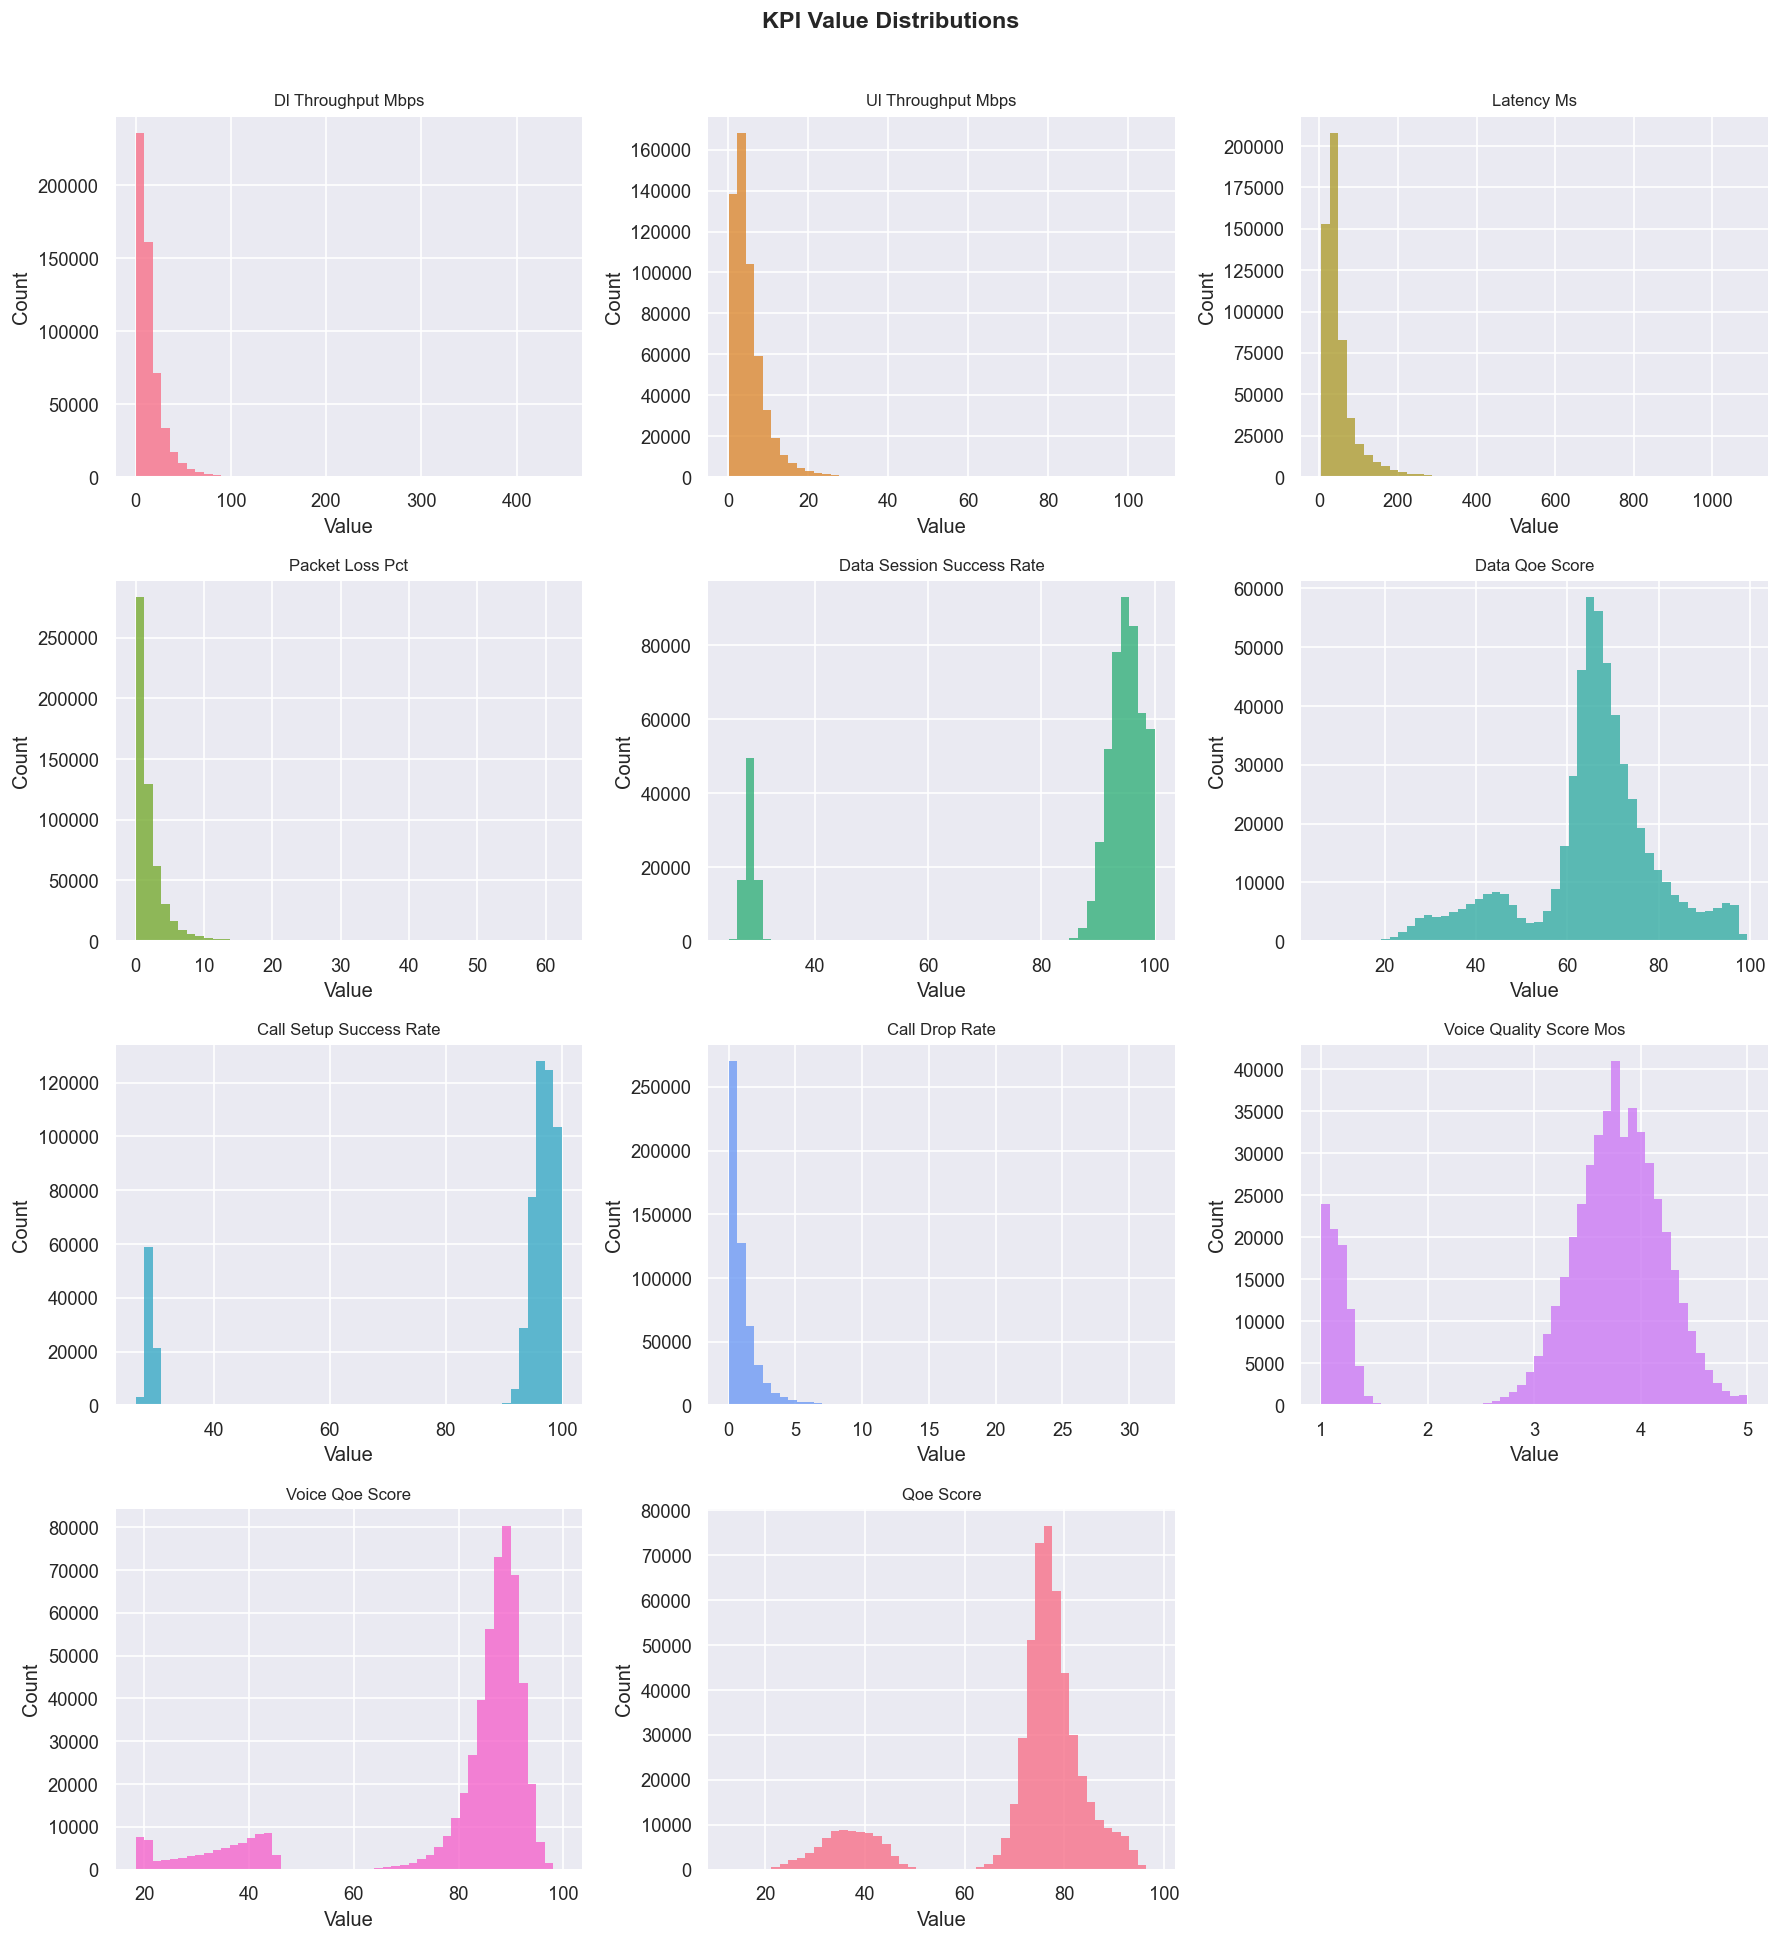

In [10]:
from src.analysis.eda import (
    kpi_distribution_plots,
    qoe_score_by_region,
    kpi_correlation_matrix,
)

fig = kpi_distribution_plots(kpi_data)
plt.show()

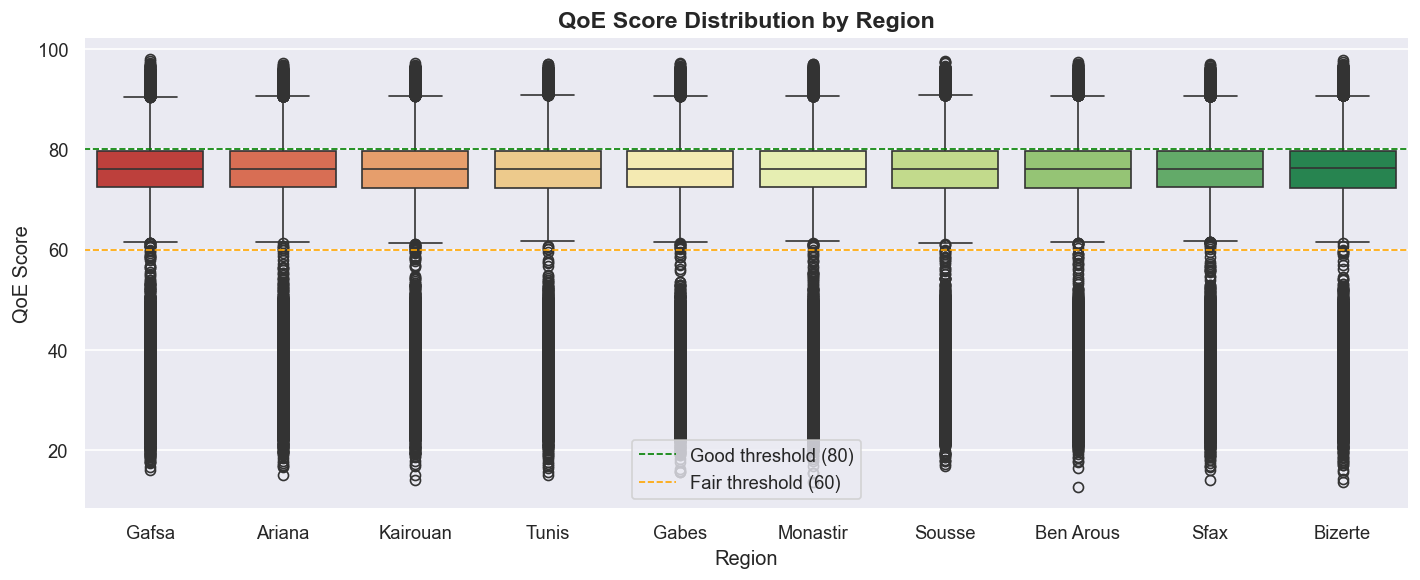

In [11]:
fig = qoe_score_by_region(kpi_data)
plt.show()

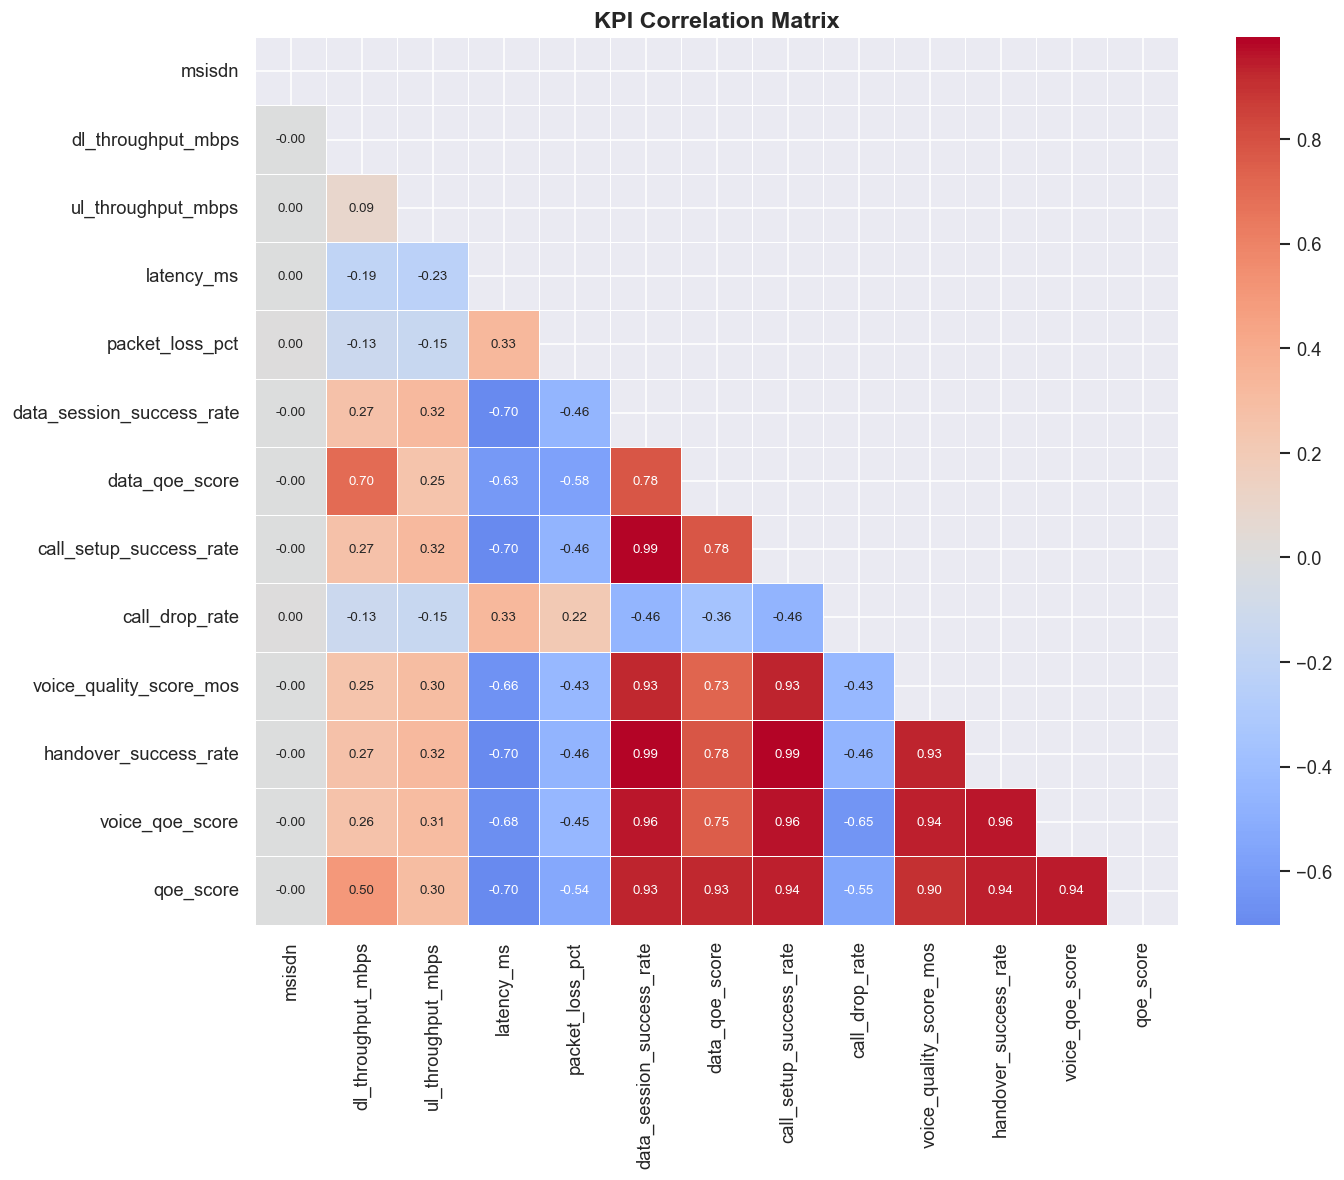

In [12]:
fig = kpi_correlation_matrix(kpi_data)
plt.show()

## 5. Data Quality Audit

In [13]:
print('=== COMPLAINT DATA — Missing Values ===')
display(missing_value_report(complaints, 'Complaints'))

print('\n=== KPI DATA — Missing Values ===')
display(missing_value_report(kpi_data, 'KPI Data'))

2026-03-25 08:18:34.751 | INFO     | src.analysis.eda:missing_value_report:139 - Complaints: 4 columns with missing values


=== COMPLAINT DATA — Missing Values ===


,column,missing,pct,dtype
0,cell_id,1568,3.14,object
1,complaint_subcategory,1522,3.04,object
2,longitude,1466,2.93,float64
3,latitude,1448,2.90,float64


2026-03-25 08:18:34.878 | INFO     | src.analysis.eda:missing_value_report:139 - KPI Data: 4 columns with missing values



=== KPI DATA — Missing Values ===


,column,missing,pct,dtype
0,call_drop_rate,11238,2.03,float64
1,latency_ms,11109,2.01,float64
2,dl_throughput_mbps,10957,1.98,float64
3,voice_quality_score_mos,10940,1.98,float64


In [14]:
# Duplicate check
print(f'Complaint duplicates (case_id): {complaints["case_id"].duplicated().sum()}')
print(f'Complaints date range: {complaints["timestamp"].min()} → {complaints["timestamp"].max()}')
print(f'KPI date range:        {kpi_data["timestamp"].min()} → {kpi_data["timestamp"].max()}')

Complaint duplicates (case_id): 0
Complaints date range: 2023-01-01 00:05:55 → 2024-06-29 23:23:09
KPI date range:        2023-01-01 00:01:00 → 2024-06-29 23:59:00


In [1]:
import pandas as pd
import dtale
complaints = pd.read_csv("data/synthetic/complaints.csv") 

# Explorer les données avec dtale
d = dtale.show(complaints)
d.open_browser()

In [10]:
import numpy as np
import warnings

# --- MANDATORY FIX FOR SWEETVIZ + NUMPY 2.0 ---
# We must define both cases because Sweetviz calls the capitalized version
if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = DeprecationWarning

if not hasattr(np, "visibledeprecationwarning"):
    np.visibledeprecationwarning = DeprecationWarning
# ----------------------------------------------

import sweetviz as sv
import pandas as pd
import os

# Your existing logic
if not os.path.exists("reports/exports"):
    os.makedirs("reports/exports")

# Load data
complaints = pd.read_csv("data/synthetic/complaints.csv")

# Create report - This should no longer turn red!
report = sv.analyze(complaints)

# Save the report
report.show_html("reports/exports/complaint_eda_report.html")

print('Full EDA report saved → reports/exports/complaint_eda_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report reports/exports/complaint_eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Full EDA report saved → reports/exports/complaint_eda_report.html
